[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/QuantumMechanics1/blob/main/QM_py/qm1_wavepack_zadevolut.ipynb)


In [1]:
%%javascript
MathJax.Hub.Config({TeX: { equationNumbers: { autoNumber: "AMS" }}
});

<IPython.core.display.Javascript object>

## Еволюція вільних хвильових пакетів.

Для проведення аналітичних обчислень будемо використовувати Python бібліотеку
<a href="https://docs.sympy.org/0.7.2/tutorial.html#"> SymPy</a>

In [2]:
import sympy as sp
from sympy import *
import numpy as np
import matplotlib.pyplot as plt

***
__Задача:__ Проаналізувати еволюцію вільного хвильового пакета, якій у початковий момент часу визначено функцією:<br>
$$
\psi (x,0) = C\exp \left( { - {\frac{{x^{2}}}{{2\,a^{2}}}}} \right)
$$
за умови що пакет сформований з: 
- електромагнітних хвиль
- хвиль де Бройля<br>

__Рішення:__ Побудуємо графік функції густини ймовірності $\rho_{0} = |\psi(x,0)|^2$ за різних $a$ (схематично)
    
***

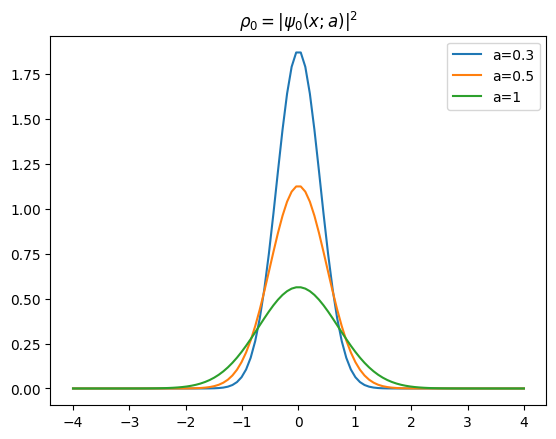

In [3]:
x=np.linspace(-4,4,100)
#
def y(x,a):
    return 1/(np.sqrt(np.pi)*a)*np.exp(-x*x/a)
#
a=[0.3,0.5,1]
#
for av in a: 
    plt.plot(x,y(x,av),label='a='+str(av))
    plt.legend()
#
plt.title('$\\rho_{0}=|\\psi_{0}(x;a)|^2$') #not simply \rho but with escape!: \\rho
plt.show()

із використанням ipywidgets

In [4]:
#%matplotlib inline
from ipywidgets import interactive

def gauss(x,x0,a):
    return np.exp(-(x-x0)**2/a**2)/(a*np.sqrt(np.pi))

def f(x0, a):
    plt.figure()
    x = np.linspace(-10, 10, num=100)
    plt.plot(x, gauss(x,x0,a))
    plt.fill_between(x,gauss(x,x0,a)) #filled region between plot and x-axis
    plt.ylim(0., 1/np.sqrt(np.pi))
    plt.title('$\\rho_{0}=|\\psi_{0}(x;a)|^2$') #not simply \rho but with escape!: \\rho
    plt.show()

interactive_plot = interactive(f, x0=(-2.0, 2.0), a=(1, 5, 0.1))
#output = interactive_plot.children[-1]
#output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='x0', max=2.0, min=-2.0), FloatSlider(value=3.0, desc…

Виконаємо нормування хвильової функції:
$$
1 =\int\limits_{-\infty}^{\infty}\,\left\vert \psi_{0} \right\vert^2\,dx\rightarrow
C = \left(\int\limits_{-\infty}^{\infty}\exp \left( { - {\frac{{(x - x_{0}
)^{2}}}{{2\,a^{2}}}}} \right)\,dx \right)^{-1/2}
$$

In [5]:
x, x0 = sp.symbols('x x0')
a=sp.Symbol('a',positive=True) # implying condition a>0
cnrm=sp.sqrt(1/sp.simplify(sp.integrate(sp.exp(-(x-x0)**2/(a**2)),[x,-oo,oo]))) # norm integral
cnrm

1/(pi**(1/4)*sqrt(a))

In [6]:
sp.latex(cnrm)

'\\frac{1}{\\sqrt[4]{\\pi} \\sqrt{a}}'

Результат:
$$C =\frac{1}{\sqrt{a\,\sqrt{\pi}}}$$

Зрозуміло, що середнє значення $$\langle x \rangle = x_0$$ 
Обчислимо величину $\langle \Delta x ^2\rangle $ у початковому стані:

In [7]:
sp.simplify(cnrm**2*sp.integrate((x-x0)**2*sp.exp(-(x-x0)**2/(a**2)),[x,-oo,oo]))

a**2/2

Результат:
$$\langle \Delta x ^2\rangle_{t=0}  =\frac{a^2}{2}$$

Еволюція пакета обчислюється відомим чином
$$	
\psi(x,t) = \frac{1}{\sqrt{2\,\pi}}\int c(k)\exp\left(i\,k\,x - i\,\omega(k)\,t\right)\,dk\,,
$$	
Випадкі пакетів з хвиль де Бройля чи з  ЕМХ відрізняються законами дисперсії: 

- $\omega = \frac{\hbar\,k^2}{2m}$
- $\omega = c\,|k|$

За початковим станом обчислюємо амплітуди $c(k)$:
***
\begin{multline*}
	c(k) = \frac{1}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty} \psi(x,0)\exp(-i\,k\,x)\, d\,x\,
	=\,\frac{C}{\sqrt{2\,\pi}}
	\int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{(x-x_0)^2}{2\,a^2}-i\,k\,x\right)\, d\,x\,
	=\\
	\frac{C\,a\,e^{-i\,k\,x_{0}}}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty}
	\exp\left(-\frac{u^2}{2}-i\,k\,a\,u\right)\, d\,u =
	\frac{C\,a}{\sqrt{2\,\pi}} \int\limits_{-\infty}^{+\infty} \exp\left(-\frac{(u +
		i\,k\,a)^2}{2}-\frac{k^2\,a^2}{2}\right)\, d\,u\, =\\
	C\,a\exp\left(-\frac{k^2\,a^2}{2}-i\,k\,x_{0}\right)
	\end{multline*}
***

У випадку квадратичного з-на дисперсії для хвиль де Бройля:
\begin{align*}
		\psi(x,t) = a\,C\,\int\limits_{-\infty}^{+\infty}\exp\left(-\frac{k^2\,a^2}{2}\,+
		\,i\,k\,(x-x_{0}) - i\,\frac{\hbar\,k^2\,t}{2\,m}\right)\,d\,k\,=&\notag\\
		\,a\,C\,\int\limits_{-\infty}^{+\infty}\exp\left(-\frac{k^2\,a(t)^2}{2}\,+
		\,i\,k\,(x-x_{0}) \right)d\,k=\frac{C}{a(t)/a}
		\exp\left(-\frac{(x-x_{0})^2}{2\,a(t)^2}\right)&\notag\\
\end{align*}
$$
a(t)=a\,\sqrt{1+i\,\frac{\hbar\,t}{m\,a^2}}\,,
$$
тобто пакет розпливається зберігая свою форму. Розрахунком переконаємось, що:
$$
\Delta x^2 =\left\langle\, x^2 \,\right\rangle- \left\langle\,\vphantom{x^2} x
\,\right\rangle^2 = \frac{|\,a(t)|^4}{2\,a^2} = \frac{a^2}{2}\,
\left(\,1+\,\frac{\hbar^2\,t^2}{m^2\,a^4}\right)
$$
<a id='gaussdispasympt'>Відмітимо асимптотики дисперсії</a>:
		\begin{align}
		\Delta x &=\frac{a}{\sqrt{2}}\left(1+\frac{\hbar^2\,t^2}{2\,m^2\,a^{\,4}}+
		o(t)\right)\,, \quad t\,\to\,0 \label{as1}\\
		\Delta x & =  \frac{\hbar}{\sqrt{2}\,m\,a}\,t\,,
		\quad t\,\to\,\infty \label{as2}
		\end{align}
Вочевидь \eqref{as1} відповідає прискоренному руху у перші моменти часу. Асимптотика \eqref{as2} відповідає розпливанню із постійною швидкістю.<br>

У випадку лінійного з-на дисперсії, характерного для ЕМХ:
$$
\psi(x,t) = a\,C\,\int\limits_{-\infty}^{+\infty}\exp\left(-\frac{k^2\,a^2}{2}\,+\,i\,k\,x - i\,c\,|k|\,t\right)\,d\,k\,=
$$
$$
\,\frac{C}{2}\,\left(\int\limits_{0}^{+\infty}\exp\left(-\frac{k^2\,a^2}{2}\,+
\,i\,k\,(x -c\,t)\right)d\,k\,\,\,+
\int\limits_{-\infty}^{0}\exp\left(-\frac{k^2\,a^2}{2}\,+
\,i\,k\,(x + c\,t)\right)\,dk \right)=
$$
$$
C\,\sqrt{\frac{\pi}{2}}\,\left( e^{-\,z_{-}^{2}/2}\left(1+{\rm erf}\left(\frac{i\,z_{-}}{
\sqrt{2}}\right)\right)+e^{-\,z_{+}^{2}/2}\left(1+{\rm erf}\left(\frac{i\,z_{+}}{ \sqrt{2}}\right)\right)\right)\,,
$$
де $z_{\pm} = x-x_{0} \pm c\,t$. Тобто пакет розпадається асимптотично ($t \to +\infty$) на два пакети. Для дійсної частини маємо простий вираз:
$$
\psi(x,t) = C\,\left( \exp{\left(-\frac{(x-c\,t)^2}{2}\right)} +  \exp{\left(-\frac{(x+c\,t)^2}{2}\right)}\right)
$$
з якого наочно можна побачити різницю в динаміці пакету в залежності від закона дисперсії.
<br>

In [8]:
def gauss2emw(x,t):
    return np.exp(-(x-t)**2/2)+np.exp(-(x+t)**2/2)
def evlemw(t=0):# fixes starting value of t
    plt.figure(2)
    x = np.linspace(-10, 10, num=1000)
    plt.plot(x, gauss2emw(x,t))
    plt.fill_between(x,gauss2emw(x,t),y2=0) #filled region between plot and x-axis
    plt.title('Evolution of EMW packet')
    plt.ylim(0,2.2-t/(t+1.5))
    plt.show()
#
interactive_plot = interactive(evlemw, t=(0, 10.0))
# output = interactive_plot.children[-1]
# output.layout.height = '500px'
interactive_plot

interactive(children=(FloatSlider(value=0.0, description='t', max=10.0), Output()), _dom_classes=('widget-inte…

In [9]:
#k, t, c = symbols('k t c')
#rectf=simplify(integrate(exp(-k**2/2)*exp(I*k*x-I*c*k*t),[k,0,+oo]) + integrate(exp(-k**2/2)*exp(I*k*x+I*c*k*t),[k,-oo,0]))
#plot(re(rectf.subs(c,1).subs(t,tt)),(x,-10,10))
#tt = np.linspace(0.5,5,10)
#for i in tt:
#    plot(re(rectf.subs(c,1).subs(t,i)),(x,-10,10),title='EMW evolution t = '+str(i),ylabel=False)

__Приклад: Еволюція прямокутного пакета__ Аналогічно розглянемо еволюцію стана який в початковий момент часу задан прямокутним пакетом
$$\psi(x,0) = \frac{1}{\sqrt{2}}\,\Pi(x) \Rightarrow c(k) = \frac{1}{\sqrt{\pi}}\frac{\sin k}{k}$$
$$
\psi(x,t) = \frac{1}{\pi}\,\int\limits_{-\infty}^{+\infty}\,\frac{\sin k}{k}\,e^{i\,k\,x - k^2\,t}\,dk 
$$

Нажаль Sympy поки ще не вміє розпізнавати інтеграли Френеля:

In [10]:
# x,k,t = sp.symbols('x k t',real=True)
# sp.integrate(sp.sin(k)/k*sp.cos(k*x-k**2*t),[k,-oo,+oo])

[тому скористаємось результатом з Mathematica](./rectwv_fresnel.ipynb):
$$\psi(x,t) = \frac{e^{i\,\pi/4}}{2}\left(
FresnelS\left(\frac{x+1}{\sqrt{2\pi t}}\right)-FresnelS\left(\frac{x-1}{\sqrt{2\pi t}}\right)\right)+\frac{e^{-i\,\pi/4}}{2}\left(
FresnelC\left(\frac{x+1}{\sqrt{2\pi t}}\right)-FresnelC\left(\frac{x-1}{\sqrt{2\pi t}}\right)\right)$$

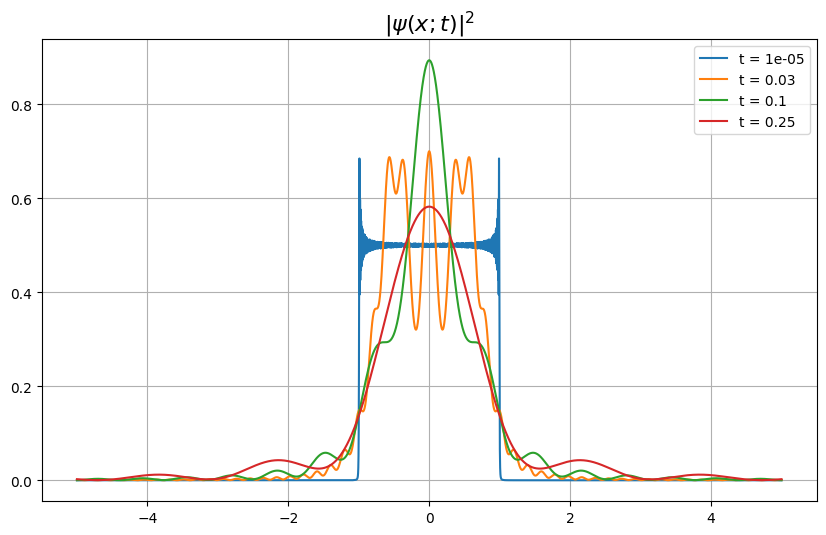

In [11]:
import matplotlib.animation as animation
import scipy.special as sc
from scipy import integrate
x0=5
def psirct(x,t):
    return 1./8*((sc.fresnel((x+1.)/np.sqrt(2.*np.pi*t))[1]-
                sc.fresnel((x-1.)/np.sqrt(2.*np.pi*t))[1]+
                sc.fresnel((x+1.)/np.sqrt(2.*np.pi*t))[0]-
                sc.fresnel((x-1.)/np.sqrt(2.*np.pi*t))[0])**2+
               (-sc.fresnel((x+1.)/np.sqrt(2.*np.pi*t))[1]+
                sc.fresnel((x-1.)/np.sqrt(2.*np.pi*t))[1]+
                sc.fresnel((x+1.)/np.sqrt(2.*np.pi*t))[0]-
                sc.fresnel((x-1.)/np.sqrt(2.*np.pi*t))[0])**2)
#
xlist=np.linspace(-x0,x0,10**4)
#
plt.figure(figsize=(10, 6))
def rsi(x,t0):
#
    return plt.plot(x,psirct(x,t0),label='t = '+str(t0))
#

for t0 in [10**(-5),0.03,0.1,0.25]:
    rsi(xlist,t0)
#
plt.legend()
plt.title('$|\\psi(x;t)|^2$',size=16)
plt.grid(True)
plt.show()
# 

Перевіримо збереженння нормування:

In [12]:
def normrct(t):
    if t==0:
        p=1
    else: 
        p=2.*integrate.quad(psirct,0,np.inf,args=(t),limit=400)[0]
    return p
for t in np.linspace(0,1.,5):
    print(normrct(t))

1


/tmp/ipykernel_25379/2398179737.py:5: IntegrationWarning: The maximum number of subdivisions (400) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  p=2.*integrate.quad(psirct,0,np.inf,args=(t),limit=400)[0]


1.0000011254865406
0.9999866715377466
0.9999981637091387
0.9999972588540733


In [13]:
# animation

# fig, ax = plt.subplots()
# fig.set_figwidth(8)    #  ширина и
# fig.set_figheight(6)

# def animate(time):
#     ax.clear()
#     ax.set_ylim([0, 1])
#     wf = ax.plot(xlist, psirct(xlist,time),'b',linewidth=0.5)
#     ax.fill(xlist, psirct(xlist,time),color='y')
#     ax.set_title('Evolution $|\psi(x,t)|^2$ for rectangular packet',fontsize = 16)
#     return wf

# # animate(0.1)

# wf_animation = animation.FuncAnimation(fig, 
#                                       animate, 
#                                       frames=np.linspace(10**(-4), 0.3, 100),
#                                       interval = 10,
#                                       repeat = False)

# # #  save the animation as gif:
# wf_animation.save('fig_rectevolut_test.gif',writer='imagemagick', fps=10)

![Rectangularpacketevolution](./figs/fig_rectevolut_test.gif)

### Задачі для самостійної роботи:
__Задача__ Змоделювати еволюцію початкових станів вільної частинки заданих хвильовими функціями:

- $\psi(x;t=0) = C\, \exp{\left(-\frac{x^2}{2}+i\,k_{0}\,x\right)}$
<br><br>
- $\psi(x;t=0) = C\,e^{i\,k_0\,x}\,{\rm HeavisidePi}(x)$
<br><br>
- $\psi(x;t=0) = C\,e^{i\,k_0\,x}\,{\rm HeavisideLambda}(x)$
<br><br>
- $\psi(x;t=0) = e^{i\,k_0\,x}\frac{C}{1+x^2}$

Обчислити ймовірність спостереження частинки у початковій області локалізації з часом (побудувати графік). Дослідити асимптотичну поведінку $\Delta x (t)$ при $t\to 0, \infty$.
***
__Задача__ Довести, що для двох хвильових пакетів $\psi_1(x,t), \psi_2(x,t)$, які описують стани __вільної__ кванової частинки з масою $m$, ''інтеграл перекриття''
$$
\int \psi^{*}_2 \psi_1\,dx
$$
не залежить від часу.
***

__Задача__ Классична частинка з енергією $E$ рухається у одновимірній потенціальній ямі $U(x)$. Визначити ймовірність її спостереження у певному інтервалі $x_1 \le x \le x_2$ . Яку наближену хвильову функцію можна співставити такому класичному руху якщо вважати, що діюча сила дуже мала?
***
__Задача__ Обчисліть функцію Гріна $G(\mathbf{r}-\mathbf{r}',t-t_0)$ вільної частинки, тобто покажіть що рішення задачі Коши для рівнняння Шредінгера можна представити у вигляді:
$$
\psi(\mathbf{r},t) = \int G(\mathbf{r}-\mathbf{r}',t-t_0)\,\psi(\mathbf{r}',t_0)\,d\mathbf{r}'
$$